## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy

In [2]:
sns.set_theme(
    context="paper", 
    style="whitegrid", 
    font="DejaVu Sans", 
    font_scale=1.1
)

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.prop_cycle'] = plt.cycler(
    color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']
)

## Load and clean results

In [3]:
results_path = "results_benchmark.csv"
properties_path = "datasets_properties.csv"

In [4]:
properties_df = pd.read_csv(properties_path, header=0)
properties_df["category"] = pd.Categorical(properties_df["category"], categories=["Small", "Medium", "Large", "High-dimensional"], ordered=True)
properties_df["anomaly_ratio"] = pd.Categorical(properties_df["anomaly_ratio"], categories=['< 3%', '3% - 8%', '8% - 13%', '13% - 25%', '> 25%'], ordered=True)

In [5]:
results_df = pd.read_csv(results_path, header=0)
results_df["status"] = results_df["status"].astype("category")
results_df["dataset"] = results_df["dataset"].str.split("_").str[1].str.lower()

In [6]:
# If error or timeout, define times to 0 minutes and scores to 0
results_df.loc[results_df["status"] != "ok", ["train_time", "inference_time", "total_time"]] = 0 # or 120*60
results_df.loc[results_df["status"] != "ok", ["auroc", "auprc"]] = 0

In [7]:
results_ok_df = results_df[results_df["status"] == "ok"].copy()
results_ok_df = results_df.copy()

In [8]:
print(f"{len(results_df) - len(results_ok_df)} results failed. Got {len(results_ok_df)} results.")

0 results failed. Got 6580 results.


In [9]:
results_ok_df = results_ok_df.sort_values(["dataset", "algorithm"]).reset_index(drop=True)
results_ok_df = results_ok_df.merge(properties_df, on="dataset", how="left")

In [10]:
results_ok_df

,dataset,algorithm,repeat,train_time,inference_time,total_time,auroc,auprc,status,number,N,d,n_ano,ano_rate,category,anomaly_ratio
0,aloi,CBLOF,1,25.896137,0.350674,26.246834,0.571192,0.040961,ok,1,49534,27,1508,3.04,Large,3% - 8%
1,aloi,CBLOF,2,8.481198,0.109691,8.590909,0.538827,0.035107,ok,1,49534,27,1508,3.04,Large,3% - 8%
2,aloi,CBLOF,3,14.537420,0.078387,14.615824,0.541535,0.035155,ok,1,49534,27,1508,3.04,Large,3% - 8%
3,aloi,CBLOF,4,13.031477,0.137933,13.169423,0.562017,0.038451,ok,1,49534,27,1508,3.04,Large,3% - 8%
4,aloi,CBLOF,5,6.036979,0.142544,6.179534,0.547070,0.039424,ok,1,49534,27,1508,3.04,Large,3% - 8%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6575,yeast,UCG,1,0.000239,3.263724,3.263990,0.472409,0.323874,ok,47,1484,8,507,34.16,Medium,> 25%
6576,yeast,UCG,2,0.000234,5.951607,5.951871,0.446182,0.311518,ok,47,1484,8,507,34.16,Medium,> 25%
6577,yeast,UCG,3,0.000189,5.691255,5.691467,0.516559,0.340395,ok,47,1484,8,507,34.16,Medium,> 25%
6578,yeast,UCG,4,0.000243,6.503759,6.504030,0.454887,0.304198,ok,47,1484,8,507,34.16,Medium,> 25%


In [11]:
df_mean = results_ok_df.groupby(['dataset', 'algorithm'], observed=False)[['auprc', "auroc", "train_time", "inference_time", "total_time"]].mean().reset_index()

# 1. Extract the base name of the algorithm
df_mean['algorithm_base'] = df_mean['algorithm'].str.replace(r'_\d+$', '', regex=True)

# 2. Identify the best version per dataset and algorithm_base (based on the average auprc)
best_combinations = df_mean.loc[
    df_mean.groupby(['dataset', 'algorithm_base'])['auprc'].idxmax()
].copy()

# 3. Filter to keep ALL the repeats of these best combinations
best_versions = results_ok_df.merge(
    best_combinations[['dataset', 'algorithm', 'algorithm_base']], 
    on=['dataset', 'algorithm']
)
best_versions = best_versions.rename(columns={'algorithm': 'algorithm_best', 'algorithm_base': 'algorithm'})

print("Best versions by base algorithm and dataset (all repeats):")
best_versions

Best versions by base algorithm and dataset (all repeats):


,dataset,algorithm_best,repeat,train_time,inference_time,total_time,auroc,auprc,status,number,N,d,n_ano,ano_rate,category,anomaly_ratio,algorithm
0,aloi,CBLOF,1,25.896137,0.350674,26.246834,0.571192,0.040961,ok,1,49534,27,1508,3.04,Large,3% - 8%,CBLOF
1,aloi,CBLOF,2,8.481198,0.109691,8.590909,0.538827,0.035107,ok,1,49534,27,1508,3.04,Large,3% - 8%,CBLOF
2,aloi,CBLOF,3,14.537420,0.078387,14.615824,0.541535,0.035155,ok,1,49534,27,1508,3.04,Large,3% - 8%,CBLOF
3,aloi,CBLOF,4,13.031477,0.137933,13.169423,0.562017,0.038451,ok,1,49534,27,1508,3.04,Large,3% - 8%,CBLOF
4,aloi,CBLOF,5,6.036979,0.142544,6.179534,0.547070,0.039424,ok,1,49534,27,1508,3.04,Large,3% - 8%,CBLOF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3755,yeast,UCG,1,0.000239,3.263724,3.263990,0.472409,0.323874,ok,47,1484,8,507,34.16,Medium,> 25%,UCG
3756,yeast,UCG,2,0.000234,5.951607,5.951871,0.446182,0.311518,ok,47,1484,8,507,34.16,Medium,> 25%,UCG
3757,yeast,UCG,3,0.000189,5.691255,5.691467,0.516559,0.340395,ok,47,1484,8,507,34.16,Medium,> 25%,UCG
3758,yeast,UCG,4,0.000243,6.503759,6.504030,0.454887,0.304198,ok,47,1484,8,507,34.16,Medium,> 25%,UCG


In [12]:
# Which versions are better for UCF ?
best_versions[best_versions["algorithm"] == "UCF"].groupby("dataset")["algorithm_best"].unique().value_counts()

algorithm_best
[UCF_2]    20
[UCF_7]    10
[UCF_8]     5
[UCF_3]     5
[UCF_6]     3
[UCF_4]     2
[UCF_5]     2
Name: count, dtype: int64

In [13]:
# Which versions are better for DyCF ?
best_versions[best_versions["algorithm"] == "DyCF"].groupby("dataset")["algorithm_best"].unique().value_counts()

algorithm_best
[DyCF_2]    30
[DyCF_3]     9
[DyCF_5]     5
[DyCF_4]     3
Name: count, dtype: int64

In [14]:
# Which versions are better for KernelCF ?
best_versions[best_versions["algorithm"] == "KernelCF_lin"].groupby("dataset")["algorithm_best"].unique().value_counts()

algorithm_best
[KernelCF_lin_2]    33
[KernelCF_lin_5]    11
[KernelCF_lin_4]     2
[KernelCF_lin_3]     1
Name: count, dtype: int64

## Utils

### Plots

In [15]:
def heatmap_col_normalized(pivot, figsize=(16, 6), cmap='viridis', fmt='.3f', **kwargs):
    """
    Heatmap with normalization by column and automatically colored text
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Store original min/max for colorbar
    vmin_global = pivot.min().min()
    vmax_global = pivot.max().max()
    
    # Normaliser chaque colonne individuellement (0-1)
    pivot_normalized = (pivot - pivot.min(axis=0)) / (pivot.max(axis=0) - pivot.min(axis=0) + 1e-10)
    columns_zero_sum = pivot_normalized.columns[pivot_normalized.sum(axis=0) == 0]
    pivot_normalized[columns_zero_sum] = 1
    
    # Création de la heatmap avec pcolormesh pour avoir contrôle sur chaque cellule
    im = ax.pcolormesh(pivot_normalized, cmap=cmap, **kwargs)
    
    # Configurer les ticks
    ax.set_yticks(np.arange(0.5, len(pivot) + 0.5, 1))
    ax.set_xticks(np.arange(0.5, len(pivot.columns) + 0.5, 1))
    ax.set_xticklabels(pivot.columns, rotation=90, ha='right')
    ax.set_yticklabels(pivot.index)
    
    # Pour chaque cellule, calculer la couleur du texte selon la luminosité du fond
    for i in range(len(pivot)):
        for j in range(len(pivot.columns)):
            value = pivot.iloc[i, j]
            norm_val = pivot_normalized.iloc[i, j]
            
            if cmap.endswith("_r"):
                text_color = 'black' if norm_val < 0.5 else 'white'
            else:
                text_color = 'white' if norm_val < 0.5 else 'black'
            
            ax.text(j + 0.5, i + 0.5, f'{value:{fmt}}', 
                   ha='center', va='center', color=text_color)
    
    plt.colorbar(im, ax=ax, shrink=0.9)    
    return fig, ax

In [16]:
def create_heatmap_performance(df, metric, metric_name, x="dataset", y="algorithm", figsize=(16, 6), cmap="viridis", info=""):
    """
    Creates a heatmap of average performance by algorithm and dataset type.
    """
    pivot = df.pivot_table(values=metric, index=y, columns=x, aggfunc='mean', observed=False)
    
    fig = plt.figure(figsize=figsize)
    heatmap_col_normalized(pivot, figsize, cmap, fmt='.3f', linewidths=0.5)
    title = f"Mean {metric_name} Performance Heatmap"
    if info != "":
        title += f" - {info}"
    plt.title(title, fontdict={"size": 14})
    plt.xlabel(x)
    plt.ylabel(y)
    
    plt.tight_layout()
    return fig

In [17]:
def create_boxplot(df, x="algorithm", y="auprc", metric_name="AUPRC", ascending=True, rank=True, groupby="dataset", ascending_groupby=False, figsize=(16, 6), cmap="viridis", info="", palette=None, logscale=False, violin=True):
    title = f"Boxplot of {metric_name}"

    if rank:
        df = df.copy()
        df = df.groupby([x, groupby], observed=False)[y].mean().reset_index()
        df["rank"] = df.groupby(groupby, observed=False)[y].rank(ascending=ascending_groupby, method="min")
        y = "rank"
        title += " rank"
        metric_name += " rank"

    order = df.groupby(x, observed=False)[y].median().reset_index().sort_values(by=y, ascending=ascending)[x]

    if info != "":
        title += f" - {info}"
    
    hue = None if palette is None else x
    fig = plt.figure(figsize=figsize)
    if violin:
        sns.violinplot(x=x, y=y, hue=hue, data=df, order=order,  palette=palette, legend=False, dodge=False, native_scale=True, inner_kws=dict(whis_width=2))
    else:
        sns.boxplot(x=x, y=y, hue=hue, data=df, order=order,  palette=palette, legend=False, showmeans=True, meanprops={"marker": "x", "markerfacecolor": "red", "markeredgecolor": "red", "markersize": "10"}, dodge=False)
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(metric_name)
    if logscale:
        plt.yscale("log")
    plt.tight_layout()
    return fig

### Summary

In [18]:
def create_algorithm_summary(df, columns="algorithm"):
    """
    Create a summary table with the means and standard deviations by algorithm.
    """
    summary = df.groupby(columns, observed=False).agg({
        'auroc': ['mean', 'std'],
        'auprc': ['mean', 'std'],
        'train_time': ['mean', 'std'],
        'inference_time': ['mean', 'std'],
        'total_time': ['mean', 'std']
    }).round(4)
    
    summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
    summary = summary.reset_index()
    
    return summary

In [19]:
def compute_pivot_df(best_versions, metric, per_sample=False, filter_nok=False):
    # 1. Calculate the mean and standard deviation of AUPRC using a dataset and algorithm
    summary_df = best_versions.groupby(['dataset', 'algorithm'])[metric].agg(['mean', 'std'])

    if filter_nok:
        groups_with_non_ok = best_versions.groupby(['dataset', 'algorithm'])['status'].apply(lambda x: not all(s == 'ok' for s in x))
        summary_df.loc[summary_df.index.intersection(groups_with_non_ok[groups_with_non_ok].index), ['mean', 'std']] = np.nan
    summary_df = summary_df.reset_index()

    if per_sample:
        summary_df = summary_df.merge(properties_df[["dataset", "N"]], on=["dataset"], how="left")
        summary_df["mean"] = summary_df["mean"] / (0.3*summary_df["N"]) # Replace by test_size_ratio
        summary_df["std"] = summary_df["std"] / (0.3*summary_df["N"]) # Replace by test_size_ratio
    
    #2. Pivot to have columnar algorithms (MultiIndex)
    pivot_df = summary_df.pivot(index='dataset', columns='algorithm', values=['mean', 'std'])
    pivot_df.columns = pivot_df.columns.swaplevel(0, 1)
    pivot_df = pivot_df.sort_index(axis=1)
    return pivot_df

In [20]:
def plot_res(crop_df, title):
    print(title)
    
    method_order = crop_df.groupby("algorithm", observed=False)["auprc"].mean().sort_values().index.tolist()
    df = crop_df.copy()
    df["algorithm"] = pd.Categorical(df["algorithm"], categories=method_order, ordered=True)

    # Parallel coordinates
    df_para = df.copy()
    ordre_methods_para = df_para.groupby("dataset")["auprc"].mean().sort_values().index.tolist()
    df_para["dataset"] = pd.Categorical(df["dataset"], categories=ordre_methods_para, ordered=True)
    fig = plt.figure(figsize=(16, 6))
    sns.lineplot(df_para.groupby(["algorithm", "dataset"])["auprc"].mean().reset_index(), x="dataset", y="auprc", hue="algorithm")
    plt.legend(bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

    # Heatmap
    df = df.sort_values("algorithm")
    create_heatmap_performance(df, "auroc", "AUROC", cmap="hot_r", info=title)
    create_heatmap_performance(df, "auprc", "AUPRC", cmap="hot_r", info=title)
    create_heatmap_performance(df, "train_time", "Training Time (s)", cmap="hot", info=title)
    create_heatmap_performance(df, "inference_time", "Inference Time (s)", cmap="hot", info=title)
    create_heatmap_performance(df, "total_time", "Total Execution Time (s)", cmap="hot", info=title)

    n_algorithm = df["algorithm"].nunique()
    palette = sns.color_palette("husl", n_algorithm)

    # Rank boxplot
    create_boxplot(df, y="auroc", metric_name="AUROC", rank=True, info=title, palette=palette)
    create_boxplot(df, y="auprc", metric_name="AUPRC", rank=True, info=title, palette=palette)
    create_boxplot(df, y="train_time", metric_name="Training Time (s)", rank=True, ascending_groupby=True, info=title,palette=palette)
    create_boxplot(df, y="inference_time", metric_name="Inference Time (s)", rank=True, ascending_groupby=True, info=title,palette=palette)
    create_boxplot(df, y="total_time", metric_name="Total Execution Time (s)", rank=True, ascending_groupby=True, info=title,palette=palette)

    # Metric boxplot
    create_boxplot(df, y="auroc", metric_name="AUROC", rank=False, info=title, ascending=False, palette=palette)
    create_boxplot(df, y="auprc", metric_name="AUPRC", rank=False, info=title, ascending=False, palette=palette)
    create_boxplot(df, y="train_time", metric_name="Training Time (s)", rank=False, ascending_groupby=True, info=title, palette=palette, logscale=True)
    create_boxplot(df, y="inference_time", metric_name="Inference Time (s)", rank=False, ascending_groupby=True, info=title, palette=palette, logscale=True)
    create_boxplot(df, y="total_time", metric_name="Total Execution Time (s)", rank=False, ascending_groupby=True, info=title, palette=palette, logscale=True)
    
    print(create_algorithm_summary(df))

### CD-Diagram

In [21]:
# Author: Hassan Ismail Fawaz <hassan.ismail-fawaz@uha.fr>
#         Germain Forestier <germain.forestier@uha.fr>
#         Jonathan Weber <jonathan.weber@uha.fr>
#         Lhassane Idoumghar <lhassane.idoumghar@uha.fr>
#         Pierre-Alain Muller <pierre-alain.muller@uha.fr>
# License: GPL3

import numpy as np
import pandas as pd
import matplotlib

# matplotlib.use('agg')
import matplotlib.pyplot as plt

import operator
import math
from scipy.stats import wilcoxon
from scipy.stats import friedmanchisquare
import networkx

# inspired from orange3 https://docs.orange.biolab.si/3/data-mining-library/reference/evaluation.cd.html
def graph_ranks(avranks, names, p_values, cd=None, cdmethod=None, lowv=None, highv=None,
                width=6, textspace=1, reverse=False, filename=None, labels=False, **kwargs):
    """
    Draws a CD graph, which is used to display  the differences in methods'
    performance. See Janez Demsar, Statistical Comparisons of Classifiers over
    Multiple Data Sets, 7(Jan):1--30, 2006.

    Needs matplotlib to work.

    The image is ploted on `plt` imported using
    `import matplotlib.pyplot as plt`.

    Args:
        avranks (list of float): average ranks of methods.
        names (list of str): names of methods.
        cd (float): Critical difference used for statistically significance of
            difference between methods.
        cdmethod (int, optional): the method that is compared with other methods
            If omitted, show pairwise comparison of methods
        lowv (int, optional): the lowest shown rank
        highv (int, optional): the highest shown rank
        width (int, optional): default width in inches (default: 6)
        textspace (int, optional): space on figure sides (in inches) for the
            method names (default: 1)
        reverse (bool, optional):  if set to `True`, the lowest rank is on the
            right (default: `False`)
        filename (str, optional): output file name (with extension). If not
            given, the function does not write a file.
        labels (bool, optional): if set to `True`, the calculated avg rank
        values will be displayed
    """
    try:
        import matplotlib
        import matplotlib.pyplot as plt
        from matplotlib.backends.backend_agg import FigureCanvasAgg
    except ImportError:
        raise ImportError("Function graph_ranks requires matplotlib.")

    width = float(width)
    textspace = float(textspace)

    def nth(l, n):
        """
        Returns only nth elemnt in a list.
        """
        n = lloc(l, n)
        return [a[n] for a in l]

    def lloc(l, n):
        """
        List location in list of list structure.
        Enable the use of negative locations:
        -1 is the last element, -2 second last...
        """
        if n < 0:
            return len(l[0]) + n
        else:
            return n

    def mxrange(lr):
        """
        Multiple xranges. Can be used to traverse matrices.
        This function is very slow due to unknown number of
        parameters.

        >>> mxrange([3,5])
        [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]

        >>> mxrange([[3,5,1],[9,0,-3]])
        [(3, 9), (3, 6), (3, 3), (4, 9), (4, 6), (4, 3)]

        """
        if not len(lr):
            yield ()
        else:
            # it can work with single numbers
            index = lr[0]
            if isinstance(index, int):
                index = [index]
            for a in range(*index):
                for b in mxrange(lr[1:]):
                    yield tuple([a] + list(b))

    def print_figure(fig, *args, **kwargs):
        canvas = FigureCanvasAgg(fig)
        canvas.print_figure(*args, **kwargs)

    sums = avranks

    nnames = names
    ssums = sums

    if lowv is None:
        lowv = min(1, int(math.floor(min(ssums))))
    if highv is None:
        highv = max(len(avranks), int(math.ceil(max(ssums))))

    cline = 0.4

    k = len(sums)

    lines = None

    linesblank = 0
    scalewidth = width - 2 * textspace

    def rankpos(rank):
        if not reverse:
            a = rank - lowv
        else:
            a = highv - rank
        return textspace + scalewidth / (highv - lowv) * a

    distanceh = 0.25

    cline += distanceh

    # calculate height needed height of an image
    minnotsignificant = max(2 * 0.2, linesblank)
    height = cline + ((k + 1) / 2) * 0.2 + minnotsignificant

    fig = plt.figure(figsize=(width, height))
    fig.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1])  # reverse y axis
    ax.set_axis_off()

    hf = 1. / height  # height factor
    wf = 1. / width

    def hfl(l):
        return [a * hf for a in l]

    def wfl(l):
        return [a * wf for a in l]

    # Upper left corner is (0,0).
    ax.plot([0, 1], [0, 1], c="w")
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)

    def line(l, color='k', **kwargs):
        """
        Input is a list of pairs of points.
        """
        ax.plot(wfl(nth(l, 0)), hfl(nth(l, 1)), color=color, **kwargs)

    def text(x, y, s, *args, **kwargs):
        ax.text(wf * x, hf * y, s, *args, **kwargs)

    line([(textspace, cline), (width - textspace, cline)], linewidth=2)

    bigtick = 0.3
    smalltick = 0.15
    linewidth = 2.0
    linewidth_sign = 4.0

    tick = None
    for a in list(np.arange(lowv, highv, 0.5)) + [highv]:
        tick = smalltick
        if a == int(a):
            tick = bigtick
        line([(rankpos(a), cline - tick / 2),
              (rankpos(a), cline)],
             linewidth=2)

    for a in range(lowv, highv + 1):
        text(rankpos(a), cline - tick / 2 - 0.05, str(a),
             ha="center", va="bottom", size=16)

    k = len(ssums)

    def filter_names(name):
        return name

    space_between_names = 0.24

    for i in range(math.ceil(k / 2)):
        chei = cline + minnotsignificant + i * space_between_names
        line([(rankpos(ssums[i]), cline),
              (rankpos(ssums[i]), chei),
              (textspace - 0.1, chei)],
             linewidth=linewidth)
        if labels:
            text(textspace + 0.3, chei - 0.075, format(ssums[i], '.4f'), ha="right", va="center", size=10)
        text(textspace - 0.2, chei, filter_names(nnames[i]), ha="right", va="center", size=16)

    for i in range(math.ceil(k / 2), k):
        chei = cline + minnotsignificant + (k - i - 1) * space_between_names
        line([(rankpos(ssums[i]), cline),
              (rankpos(ssums[i]), chei),
              (textspace + scalewidth + 0.1, chei)],
             linewidth=linewidth)
        if labels:
            text(textspace + scalewidth - 0.3, chei - 0.075, format(ssums[i], '.4f'), ha="left", va="center", size=10)
        text(textspace + scalewidth + 0.2, chei, filter_names(nnames[i]),
             ha="left", va="center", size=16)

    # no-significance lines
    def draw_lines(lines, side=0.05, height=0.1):
        start = cline + 0.2

        for l, r in lines:
            line([(rankpos(ssums[l]) - side, start),
                  (rankpos(ssums[r]) + side, start)],
                 linewidth=linewidth_sign)
            start += height
            # print('drawing: ', l, r)

    # draw_lines(lines)
    start = cline + 0.2
    side = -0.02
    height = 0.1

    # draw no significant lines
    # get the cliques
    cliques = form_cliques(p_values, nnames)
    i = 1
    achieved_half = False
    # print(nnames)
    for clq in cliques:
        if len(clq) == 1:
            continue
        # print(clq)
        min_idx = np.array(clq).min()
        max_idx = np.array(clq).max()
        if min_idx >= len(nnames) / 2 and achieved_half == False:
            start = cline + 0.25
            achieved_half = True
        line([(rankpos(ssums[min_idx]) - side, start),
              (rankpos(ssums[max_idx]) + side, start)],
             linewidth=linewidth_sign)
        start += height


def form_cliques(p_values, nnames):
    """
    This method forms the cliques
    """
    # first form the numpy matrix data
    m = len(nnames)
    g_data = np.zeros((m, m), dtype=np.int64)
    for p in p_values:
        if p[3] == False:
            i = np.where(nnames == p[0])[0][0]
            j = np.where(nnames == p[1])[0][0]
            min_i = min(i, j)
            max_j = max(i, j)
            g_data[min_i, max_j] = 1

    g = networkx.Graph(g_data)
    return networkx.find_cliques(g)


def draw_cd_diagram(df, algorithms="algorithm", datasets="dataset", metric="auprc", alpha=0.05, title=None, labels=False, info="", dir_=""):
    """
    Draws the critical difference diagram given the list of pairwise classifiers that are
    significant or not
    """
    df_perf = df.groupby([algorithms, datasets])[metric].mean().reset_index()[[algorithms, datasets, metric]].copy()
    df_perf.columns = ["classifier_name", "dataset_name", "accuracy"]
    
    p_values, average_ranks, _ = wilcoxon_holm(df_perf=df_perf, alpha=alpha)

    # print(average_ranks)

    # for p in p_values:
    #     print(p)


    graph_ranks(average_ranks.values, average_ranks.keys(), p_values,
                cd=None, reverse=True, width=9, textspace=1.5, labels=labels)

    font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }
    if title:
        plt.title(title,fontdict=font, y=0.9, x=0.5)
    if info != "" or dir_ != "":
        plt.savefig(f'{dir_}cd_diagram_{metric}{info}.png',bbox_inches='tight')

def wilcoxon_holm(alpha=0.05, df_perf=None):
    """
    Applies the wilcoxon signed rank test between each pair of algorithm and then use Holm
    to reject the null's hypothesis
    """
    # print(pd.unique(df_perf['classifier_name']))
    # count the number of tested datasets per classifier
    df_counts = pd.DataFrame({'count': df_perf.groupby(
        ['classifier_name']).size()}).reset_index()
    # get the maximum number of tested datasets
    max_nb_datasets = df_counts['count'].max()
    # get the list of classifiers who have been tested on nb_max_datasets
    classifiers = list(df_counts.loc[df_counts['count'] == max_nb_datasets]
                       ['classifier_name'])
    # test the null hypothesis using friedman before doing a post-hoc analysis
    friedman_p_value = friedmanchisquare(*(
        np.array(df_perf.loc[df_perf['classifier_name'] == c]['accuracy'])
        for c in classifiers))[1]
    if friedman_p_value >= alpha:
        # then the null hypothesis over the entire classifiers cannot be rejected
        print('the null hypothesis over the entire classifiers cannot be rejected')
        exit()
    # get the number of classifiers
    m = len(classifiers)
    # init array that contains the p-values calculated by the Wilcoxon signed rank test
    p_values = []
    # loop through the algorithms to compare pairwise
    for i in range(m - 1):
        # get the name of classifier one
        classifier_1 = classifiers[i]
        # get the performance of classifier one
        perf_1 = np.array(df_perf.loc[df_perf['classifier_name'] == classifier_1]['accuracy']
                          , dtype=np.float64)
        for j in range(i + 1, m):
            # get the name of the second classifier
            classifier_2 = classifiers[j]
            # get the performance of classifier one
            perf_2 = np.array(df_perf.loc[df_perf['classifier_name'] == classifier_2]
                              ['accuracy'], dtype=np.float64)
            # calculate the p_value
            p_value = wilcoxon(perf_1, perf_2, zero_method='pratt')[1]
            # appen to the list
            p_values.append((classifier_1, classifier_2, p_value, False))
    # get the number of hypothesis
    k = len(p_values)
    # sort the list in acsending manner of p-value
    p_values.sort(key=operator.itemgetter(2))

    # loop through the hypothesis
    for i in range(k):
        # correct alpha with holm
        new_alpha = float(alpha / (k - i))
        # test if significant after holm's correction of alpha
        if p_values[i][2] <= new_alpha:
            p_values[i] = (p_values[i][0], p_values[i][1], p_values[i][2], True)
        else:
            # stop
            break
    # compute the average ranks to be returned (useful for drawing the cd diagram)
    # sort the dataframe of performances
    sorted_df_perf = df_perf.loc[df_perf['classifier_name'].isin(classifiers)]. \
        sort_values(['classifier_name', 'dataset_name'])
    # get the rank data
    rank_data = np.array(sorted_df_perf['accuracy']).reshape(m, max_nb_datasets)

    # create the data frame containg the accuracies
    df_ranks = pd.DataFrame(data=rank_data, index=np.sort(classifiers), columns=
    np.unique(sorted_df_perf['dataset_name']))

    # number of wins
    dfff = df_ranks.rank(ascending=False)
    # print(dfff[dfff == 1.0].sum(axis=1))

    # average the ranks
    average_ranks = df_ranks.rank(ascending=False).mean(axis=1).sort_values(ascending=False)
    # return the p-values and the average ranks
    return p_values, average_ranks, max_nb_datasets

### Latex

In [22]:
def format_cell(mean_val, std_val, formatter):
    """Format a cell using mean ± std notation"""
    if pd.isna(mean_val) or pd.isna(std_val):
        return "$-$"
    return f"{mean_val:{formatter}} $\\pm$ {std_val:{formatter}}"

def format_average_line(df, algorithms, ascending=False, before="", formatter=".3f"):
    averages = df.mean().xs("mean", level=1)
    std = df.std().xs("mean", level=1)
    sorted_averages_idx = averages.rank(ascending=ascending, method="min").sort_values().index

    average_line = before + "& Average & "
    for alg in algorithms:
        formatted = format_cell(averages[alg], std[alg], formatter=formatter)
        if alg == sorted_averages_idx[0]:
            average_line += f"\\textbf{{{formatted}}}"
        elif alg == sorted_averages_idx[1]:
            average_line += f"\\underline{{{formatted}}}"
        else:
            average_line += formatted
        average_line += " & "
    return average_line[:-2] + r"\\"
        
def create_latex_table(df, caption, label, resize_width, ascending=False, regroup_by="category", formatter=".3f"):
    """Convert the dataframe into a LaTeX table with bold/underline"""
    algorithms = df.columns.get_level_values(0).unique()
    replacement_map = {"KernelCF_lin": "KernelCF (lin)", "KernelCF_rbf": "KernelCF (RBF)"}
    lines = []
    lines.append(r"\begin{table}[h]")
    lines.append(r"\centering")
    lines.append(r"\caption{" + caption + "}")
    lines.append(r"\vspace{-2em}")
    cat_caption = "AR means Anomaly Ratio" if regroup_by == "anomaly_ratio" else "Cat means Category"
    lines.append(r"\caption*{\small Best result in \textbf{bold}, second-best \underline{underlined}. " + cat_caption + ".}")
    lines.append(r"\resizebox{" + resize_width + "}{!}{%")
    lines.append(r"\begin{tabular}{cl" + "c" * len(algorithms) + "}")
    lines.append(r"\toprule")

    cat_header = "AR" if regroup_by == "anomaly_ratio" else "Cat"
    # Header avec algorithmes
    lines.append(r"\textbf{" + cat_header + r"} & \textbf{Dataset} & \textbf{" + r"} & \textbf{".join([replacement_map.get(alg, alg) for alg in algorithms]) + r"} \\")
    lines.append(r"\midrule")

    for cat in properties_df[regroup_by].cat.categories.tolist():
        cat_datasets = properties_df[properties_df[regroup_by] == cat]["dataset"].tolist()
        for n_dataset, dataset in enumerate(cat_datasets):
            row = df.loc[dataset]
            # Trouver les meilleures valeurs pour ce dataset
            values = np.array([(row[(alg, 'mean')], row[(alg, 'std')]) for alg in algorithms])

            values_to_rank = values[:, 0] if ascending else -values[:, 0]
            rank_values = scipy.stats.rankdata(values_to_rank, method="min")
            
            # Formater chaque cellule
            cells = []
            for n_value, (mean_val, std_val) in enumerate(values):
                formatted = format_cell(mean_val, std_val, formatter=formatter)
                
                # Mettre en forme selon le rang
                rank = rank_values[n_value]
                if rank == 1:
                    formatted = f"\\textbf{{{formatted}}}"  # Plus haut
                elif rank == 2:
                    formatted = f"\\underline{{{formatted}}}"  # Deuxième
                cells.append(formatted)

            if n_dataset == 0:
                cat_str = cat.replace("<", "$<$").replace(">", "$>$").replace("%", r"\%")
                header_cat = r"\multirow{" + str(len(cat_datasets) + 1) + r"}{*}{\rotatebox{90}{\textbf{" + cat_str + "}}} & " #" data sets}}} & "
            else:
                header_cat = "& "
            lines.append(header_cat + r"\textbf{" + dataset + "} & " + " & ".join(cells) + r" \\")
        lines.append(r"\cdashline{2-" + str(len(algorithms) + 2) + "}")
        lines.append(format_average_line(df[df.index.isin(cat_datasets)], algorithms, ascending=ascending, formatter=formatter))
        lines.append(r"\midrule")
        
    lines.append(r"\midrule")
    lines.append(format_average_line(df, algorithms, ascending=ascending, before=r"\textbf{All} ", formatter=formatter))
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append("}%")
    lines.append(r"\label{" + label + "}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)

In [23]:
def format_average_line_by_category(df, algorithms, category, ascending=False, formatter=".3f"):
    """Format an average line for a given category."""
    values = []
    for alg in algorithms:
        mean_val = df[(alg, 'mean')].mean()
        std_val = df[(alg, 'std')].mean()
        values.append((mean_val, std_val))

    values_to_rank = np.array([v[0] for v in values])
    if not ascending:
        values_to_rank = -values_to_rank
    rank_values = scipy.stats.rankdata(values_to_rank, method="min")

    cells = []
    for n_value, (mean_val, std_val) in enumerate(values):
        formatted = format_cell(mean_val, std_val, formatter=formatter)
        rank = rank_values[n_value]
        if rank == 1:
            formatted = f"\\textbf{{{formatted}}}"
        elif rank == 2:
            formatted = f"\\underline{{{formatted}}}"
        cells.append(formatted)
    return " & ".join(cells)

def create_latex_table_by_cat(df, caption, label, resize_width, ascending=False, regroup_by="category", formatter=".3f"):
    """Convert the dataframe into a LaTeX table with one row per algorithm, one column per category, and one 'All' column."""
    algorithms = df.columns.get_level_values(0).unique()
    categories = properties_df[regroup_by].cat.categories.tolist()
    replacement_map = {"KernelCF_lin": "KernelCF (lin)", "KernelCF_rbf": "KernelCF (RBF)"}

    lines = []
    lines.append(r"\begin{table}[h]")
    lines.append(r"\centering")
    lines.append(r"\caption{" + caption + "}")
    lines.append(r"\vspace{-2em}")
    lines.append(r"\caption*{\small Best result in \textbf{bold}, second-best \underline{underlined}.}")
    lines.append(r"\resizebox{" + resize_width + "}{!}{%")
    lines.append(r"\begin{tabular}{l" + "c" * (len(categories) + 1) + "}")  # +1 pour la colonne 'All'
    lines.append(r"\toprule")

    # Header: first column for algorithms, then categories, then 'All'
    cat_headers = [cat.replace("<", "$<$").replace(">", "$>$").replace("%", r"\%") for cat in categories]
    lines.append(r"\textbf{Algorithm} & \textbf{" + r"} & \textbf{".join(cat_headers) + r"} & \textbf{All} \\")
    lines.append(r"\midrule")

    # For each algorithm, calculate the average per category and the overall average.
    for alg in algorithms:
        alg_name = replacement_map.get(alg, alg)
        cells = []
        # Calculate the values ​​for each category
        for cat in categories:
            cat_datasets = properties_df[properties_df[regroup_by] == cat]["dataset"].tolist()
            cat_df = df[df.index.isin(cat_datasets)]
            mean_val = cat_df[(alg, 'mean')].mean()
            std_val = cat_df[(alg, 'std')].mean()
            cells.append((mean_val, std_val, cat_datasets))  # On garde cat_datasets pour le rang

        # Calculate the overall average for this algorithm (all datasets)
        global_mean = df[(alg, 'mean')].mean()
        global_std = df[(alg, 'std')].mean()

        # Format the cells for each category
        formatted_cells = []
        for n_cat, (mean_val, std_val, cat_datasets) in enumerate(cells):
            # Retrieve all values ​​for this category (all algorithms)
            all_values = []
            for a in algorithms:
                cat_df = df[df.index.isin(cat_datasets)]
                all_values.append(cat_df[(a, 'mean')].mean())
            values_to_rank = np.array(all_values)
            if not ascending:
                values_to_rank = -values_to_rank
            rank_values = scipy.stats.rankdata(values_to_rank, method="min")
            # Find the current algorithm's ranking for this category
            alg_index = list(algorithms).index(alg)
            rank = rank_values[alg_index]
            formatted = format_cell(mean_val, std_val, formatter=formatter)
            if rank == 1:
                formatted = f"\\textbf{{{formatted}}}"
            elif rank == 2:
                formatted = f"\\underline{{{formatted}}}"
            formatted_cells.append(formatted)

        # Format the cell for the 'All' column
        # Calculate the overall ranking for this algorithm (among all algorithms)
        all_global_means = [df[(a, 'mean')].mean() for a in algorithms]
        values_to_rank_global = np.array(all_global_means)
        if not ascending:
            values_to_rank_global = -values_to_rank_global
        rank_values_global = scipy.stats.rankdata(values_to_rank_global, method="min")
        alg_index_global = list(algorithms).index(alg)
        rank_global = rank_values_global[alg_index_global]
        formatted_global = format_cell(global_mean, global_std, formatter=formatter)
        if rank_global == 1:
            formatted_global = f"\\textbf{{{formatted_global}}}"
        elif rank_global == 2:
            formatted_global = f"\\underline{{{formatted_global}}}"

        # Add the line for this algorithm
        lines.append(r"\textbf{" + alg_name + "} & " + " & ".join(formatted_cells) + " & " + formatted_global + r" \\")

    lines.append(r"\midrule")

    # Overall average line by category (optional)
    global_cells = []
    for cat in categories:
        cat_datasets = properties_df[properties_df[regroup_by] == cat]["dataset"].tolist()
        cat_df = df[df.index.isin(cat_datasets)]
        all_means = [cat_df[(alg, 'mean')].mean() for alg in algorithms]
        all_stds = [cat_df[(alg, 'std')].mean() for alg in algorithms]
        mean_of_means = np.mean(all_means)
        mean_of_stds = np.mean(all_stds)
        global_cells.append(format_cell(mean_of_means, mean_of_stds, formatter=formatter))

    # Overall average of all algorithms across all datasets
    all_means_global = [df[(alg, 'mean')].mean() for alg in algorithms]
    all_stds_global = [df[(alg, 'std')].mean() for alg in algorithms]
    mean_of_means_global = np.mean(all_means_global)
    mean_of_stds_global = np.mean(all_stds_global)
    global_cells.append(format_cell(mean_of_means_global, mean_of_stds_global, formatter=formatter))

    lines.append(r"\textbf{Average} & " + " & ".join(global_cells) + r" \\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append("}%")
    lines.append(r"\label{" + label + "}")
    lines.append(r"\end{table}")

    return "\n".join(lines)

## Tables

In [24]:
ours = ["UCF"]
drop_cols = ["UCG"]
distance_based = ["KNN", "CBLOF", "GMM"]
distribution_based = ["KDE", "OCSVM", "HBOS", "ECOD", "LODA", "IForest", "PCA"]
christoffel_based = ["DyCF", "DyCG", "KernelCF_lin", "KernelCF_rbf"]

### Article tables

#### Summary tables

In [25]:
pivot_df = compute_pivot_df(best_versions, "auprc").drop(drop_cols, axis=1)
latex_table = create_latex_table_by_cat(pivot_df, "AP scores per datasets categories", "tab:ap_performances_summary", r"0.98\textwidth")
print(latex_table)

\begin{table}[h]
\centering
\caption{AP scores per datasets categories}
\vspace{-2em}
\caption*{\small Best result in \textbf{bold}, second-best \underline{underlined}.}
\resizebox{0.98\textwidth}{!}{%
\begin{tabular}{lccccc}
\toprule
\textbf{Algorithm} & \textbf{Small} & \textbf{Medium} & \textbf{Large} & \textbf{High-dimensional} & \textbf{All} \\
\midrule
\textbf{CBLOF} & 0.467 $\pm$ 0.097 & \underline{0.371 $\pm$ 0.070} & 0.237 $\pm$ 0.033 & \underline{0.344 $\pm$ 0.016} & 0.359 $\pm$ 0.058 \\
\textbf{DyCF} & 0.349 $\pm$ 0.079 & 0.275 $\pm$ 0.030 & 0.309 $\pm$ 0.025 & 0.049 $\pm$ 0.005 & 0.259 $\pm$ 0.037 \\
\textbf{DyCG} & 0.094 $\pm$ 0.010 & 0.043 $\pm$ 0.008 & 0.060 $\pm$ 0.002 & 0.000 $\pm$ 0.000 & 0.052 $\pm$ 0.005 \\
\textbf{ECOD} & 0.492 $\pm$ 0.086 & 0.333 $\pm$ 0.023 & 0.313 $\pm$ 0.023 & 0.256 $\pm$ 0.022 & 0.354 $\pm$ 0.039 \\
\textbf{GMM} & 0.445 $\pm$ 0.090 & 0.299 $\pm$ 0.025 & 0.303 $\pm$ 0.022 & 0.335 $\pm$ 0.020 & 0.344 $\pm$ 0.040 \\
\textbf{HBOS} & \underline{0.5

In [26]:
pivot_df = compute_pivot_df(best_versions, "auprc").drop(drop_cols, axis=1)
latex_table = create_latex_table_by_cat(pivot_df, "AP scores per datasets anomaly ratio", "tab:ap_performances_summary_ar", r"0.98\textwidth", regroup_by="anomaly_ratio")
print(latex_table)

\begin{table}[h]
\centering
\caption{AP scores per datasets anomaly ratio}
\vspace{-2em}
\caption*{\small Best result in \textbf{bold}, second-best \underline{underlined}.}
\resizebox{0.98\textwidth}{!}{%
\begin{tabular}{lcccccc}
\toprule
\textbf{Algorithm} & \textbf{$<$ 3\%} & \textbf{3\% - 8\%} & \textbf{8\% - 13\%} & \textbf{13\% - 25\%} & \textbf{$>$ 25\%} & \textbf{All} \\
\midrule
\textbf{CBLOF} & \underline{0.303 $\pm$ 0.078} & 0.318 $\pm$ 0.062 & 0.328 $\pm$ 0.053 & 0.285 $\pm$ 0.050 & 0.602 $\pm$ 0.023 & 0.359 $\pm$ 0.058 \\
\textbf{DyCF} & 0.205 $\pm$ 0.048 & 0.245 $\pm$ 0.046 & 0.215 $\pm$ 0.038 & 0.134 $\pm$ 0.012 & 0.501 $\pm$ 0.019 & 0.259 $\pm$ 0.037 \\
\textbf{DyCG} & 0.008 $\pm$ 0.005 & 0.031 $\pm$ 0.006 & 0.049 $\pm$ 0.006 & 0.050 $\pm$ 0.000 & 0.167 $\pm$ 0.008 & 0.052 $\pm$ 0.005 \\
\textbf{ECOD} & 0.264 $\pm$ 0.045 & 0.347 $\pm$ 0.048 & 0.352 $\pm$ 0.036 & 0.319 $\pm$ 0.038 & 0.549 $\pm$ 0.016 & 0.354 $\pm$ 0.039 \\
\textbf{GMM} & 0.219 $\pm$ 0.044 & 0.345 $\pm$ 0.

In [27]:
pivot_df = compute_pivot_df(best_versions, "inference_time", per_sample=True, filter_nok=True).drop(drop_cols, axis=1)
latex_table = create_latex_table_by_cat(pivot_df, "Inference time (in seconds) per samples per datasets categories", "tab:it_performances_summary", r"0.98\textwidth", ascending=True, formatter=".2e")
print(latex_table)

\begin{table}[h]
\centering
\caption{Inference time (in seconds) per samples per datasets categories}
\vspace{-2em}
\caption*{\small Best result in \textbf{bold}, second-best \underline{underlined}.}
\resizebox{0.98\textwidth}{!}{%
\begin{tabular}{lccccc}
\toprule
\textbf{Algorithm} & \textbf{Small} & \textbf{Medium} & \textbf{Large} & \textbf{High-dimensional} & \textbf{All} \\
\midrule
\textbf{CBLOF} & 2.04e-05 $\pm$ 1.81e-05 & 8.36e-05 $\pm$ 5.48e-05 & 1.22e-05 $\pm$ 5.98e-06 & 4.47e-05 $\pm$ 2.74e-05 & \underline{4.24e-05 $\pm$ 2.82e-05} \\
\textbf{DyCF} & 5.75e-02 $\pm$ 1.80e-02 & 9.19e-03 $\pm$ 1.95e-03 & 2.90e-03 $\pm$ 1.23e-03 & 7.88e-02 $\pm$ 8.31e-03 & 2.58e-02 $\pm$ 6.86e-03 \\
\textbf{DyCG} & 1.65e-01 $\pm$ 4.09e-02 & 2.05e-02 $\pm$ 4.86e-03 & 1.20e-03 $\pm$ 3.33e-04 & $-$ & 6.23e-02 $\pm$ 1.54e-02 \\
\textbf{ECOD} & 1.06e-04 $\pm$ 1.81e-04 & 6.31e-05 $\pm$ 7.59e-05 & 4.55e-05 $\pm$ 4.40e-05 & 7.39e-04 $\pm$ 4.44e-04 & 1.99e-04 $\pm$ 1.66e-04 \\
\textbf{GMM} & 4.69e-06 $\pm

#### Per dataset

In [28]:
pivot_df = compute_pivot_df(best_versions, "auprc").drop(drop_cols, axis=1)
for l, name in zip([distance_based, distribution_based, christoffel_based], ["distance", "distribution", "Christoffel"]):
    mask = pivot_df.columns.get_level_values(0).isin(l + ours)
    selected_df = pivot_df.loc[:, mask]
    latex_table = create_latex_table(selected_df, f"AP scores per ({name}) algorithms and data sets", f"tab:ap_performances_{name}", r"0.98\textwidth")
    print(latex_table)

\begin{table}[h]
\centering
\caption{AP scores per (distance) algorithms and data sets}
\vspace{-2em}
\caption*{\small Best result in \textbf{bold}, second-best \underline{underlined}. Cat means Category.}
\resizebox{0.98\textwidth}{!}{%
\begin{tabular}{clcccc}
\toprule
\textbf{Cat} & \textbf{Dataset} & \textbf{CBLOF} & \textbf{GMM} & \textbf{KNN} & \textbf{UCF} \\
\midrule
\multirow{13}{*}{\rotatebox{90}{\textbf{Small}}} & \textbf{breastw} & 0.931 $\pm$ 0.029 & \underline{0.948 $\pm$ 0.016} & 0.929 $\pm$ 0.036 & \textbf{0.967 $\pm$ 0.018} \\
& \textbf{glass} & 0.190 $\pm$ 0.047 & 0.187 $\pm$ 0.114 & \underline{0.229 $\pm$ 0.046} & \textbf{0.286 $\pm$ 0.124} \\
& \textbf{hepatitis} & 0.318 $\pm$ 0.089 & \underline{0.318 $\pm$ 0.111} & \textbf{0.347 $\pm$ 0.148} & 0.286 $\pm$ 0.108 \\
& \textbf{ionosphere} & 0.894 $\pm$ 0.026 & 0.932 $\pm$ 0.027 & \underline{0.934 $\pm$ 0.018} & \textbf{0.951 $\pm$ 0.017} \\
& \textbf{lymphography} & \underline{0.967 $\pm$ 0.075} & 0.690 $\pm$ 0.222 & \

In [29]:
pivot_df = compute_pivot_df(best_versions, "auprc").drop(drop_cols, axis=1)
for l, name in zip([distance_based, distribution_based, christoffel_based], ["distance", "distribution", "Christoffel"]):
    mask = pivot_df.columns.get_level_values(0).isin(l + ours)
    selected_df = pivot_df.loc[:, mask]
    latex_table = create_latex_table(selected_df, f"AP scores per ({name}) algorithms and data sets", f"tab:ap_performances_{name}_by_ar", r"0.98\textwidth", regroup_by="anomaly_ratio")
    print(latex_table)

\begin{table}[h]
\centering
\caption{AP scores per (distance) algorithms and data sets}
\vspace{-2em}
\caption*{\small Best result in \textbf{bold}, second-best \underline{underlined}. AR means Anomaly Ratio.}
\resizebox{0.98\textwidth}{!}{%
\begin{tabular}{clcccc}
\toprule
\textbf{AR} & \textbf{Dataset} & \textbf{CBLOF} & \textbf{GMM} & \textbf{KNN} & \textbf{UCF} \\
\midrule
\multirow{15}{*}{\rotatebox{90}{\textbf{$<$ 3\%}}} & \textbf{backdoor} & \textbf{0.548 $\pm$ 0.029} & \underline{0.541 $\pm$ 0.020} & 0.371 $\pm$ 0.017 & 0.499 $\pm$ 0.016 \\
& \textbf{celeba} & \textbf{0.087 $\pm$ 0.037} & \underline{0.080 $\pm$ 0.002} & 0.039 $\pm$ 0.001 & 0.039 $\pm$ 0.000 \\
& \textbf{cover} & \underline{0.072 $\pm$ 0.009} & \textbf{0.081 $\pm$ 0.001} & 0.037 $\pm$ 0.003 & 0.072 $\pm$ 0.001 \\
& \textbf{fraud} & \underline{0.160 $\pm$ 0.026} & 0.141 $\pm$ 0.021 & 0.070 $\pm$ 0.007 & \textbf{0.359 $\pm$ 0.053} \\
& \textbf{http} & \underline{0.469 $\pm$ 0.012} & \textbf{0.478 $\pm$ 0.013} & 0.

In [30]:
pivot_df_time = compute_pivot_df(best_versions, "total_time").drop(drop_cols, axis=1)
for l, name in zip([distance_based, distribution_based, christoffel_based], ["distance", "distribution", "Christoffel"]):
    mask = pivot_df_time.columns.get_level_values(0).isin(l + ours)
    selected_df = pivot_df_time.loc[:, mask]
    latex_table = create_latex_table(selected_df, f"Execution time (in seconds) per ({name}) algorithms and data sets", f"tab:execution_time_performances_{name}", r"0.98\textwidth", ascending=True)
    print(latex_table)

\begin{table}[h]
\centering
\caption{Execution time (in seconds) per (distance) algorithms and data sets}
\vspace{-2em}
\caption*{\small Best result in \textbf{bold}, second-best \underline{underlined}. Cat means Category.}
\resizebox{0.98\textwidth}{!}{%
\begin{tabular}{clcccc}
\toprule
\textbf{Cat} & \textbf{Dataset} & \textbf{CBLOF} & \textbf{GMM} & \textbf{KNN} & \textbf{UCF} \\
\midrule
\multirow{13}{*}{\rotatebox{90}{\textbf{Small}}} & \textbf{breastw} & 8.476 $\pm$ 3.883 & \underline{1.049 $\pm$ 0.289} & \textbf{0.007 $\pm$ 0.001} & 3.583 $\pm$ 0.696 \\
& \textbf{glass} & 8.396 $\pm$ 8.281 & \underline{0.692 $\pm$ 0.249} & \textbf{0.003 $\pm$ 0.001} & 1.142 $\pm$ 0.543 \\
& \textbf{hepatitis} & 8.645 $\pm$ 3.921 & \textbf{1.024 $\pm$ 0.120} & 1.751 $\pm$ 0.787 & \underline{1.232 $\pm$ 0.287} \\
& \textbf{ionosphere} & 8.722 $\pm$ 4.019 & \textbf{0.885 $\pm$ 0.221} & 2.234 $\pm$ 0.736 & \underline{1.216 $\pm$ 0.454} \\
& \textbf{lymphography} & 8.089 $\pm$ 4.870 & \textbf{0.982 $

In [31]:
pivot_df_time = compute_pivot_df(best_versions, "inference_time", per_sample=True, filter_nok=True)
for l, name in zip([distance_based, distribution_based, christoffel_based], ["distance", "distribution", "Christoffel"]):
    mask = pivot_df_time.columns.get_level_values(0).isin(l + ours)
    selected_df = pivot_df_time.loc[:, mask]
    latex_table = create_latex_table(selected_df, f"Inference time (in seconds) per samples per ({name}) algorithms and data sets", f"tab:inference_time_performances_{name}", r"0.98\textwidth", ascending=True,  formatter=".2e")
    print(latex_table)

\begin{table}[h]
\centering
\caption{Inference time (in seconds) per samples per (distance) algorithms and data sets}
\vspace{-2em}
\caption*{\small Best result in \textbf{bold}, second-best \underline{underlined}. Cat means Category.}
\resizebox{0.98\textwidth}{!}{%
\begin{tabular}{clcccc}
\toprule
\textbf{Cat} & \textbf{Dataset} & \textbf{CBLOF} & \textbf{GMM} & \textbf{KNN} & \textbf{UCF} \\
\midrule
\multirow{13}{*}{\rotatebox{90}{\textbf{Small}}} & \textbf{breastw} & \underline{4.29e-06 $\pm$ 4.36e-07} & \textbf{1.46e-06 $\pm$ 6.61e-08} & 8.24e-06 $\pm$ 7.27e-07 & 1.75e-02 $\pm$ 3.39e-03 \\
& \textbf{glass} & 1.14e-05 $\pm$ 1.34e-06 & \textbf{4.39e-06 $\pm$ 2.20e-07} & \underline{1.03e-05 $\pm$ 2.14e-06} & 1.78e-02 $\pm$ 8.45e-03 \\
& \textbf{hepatitis} & \underline{2.95e-05 $\pm$ 2.12e-06} & \textbf{1.19e-05 $\pm$ 8.17e-07} & 4.24e-02 $\pm$ 2.03e-02 & 5.13e-02 $\pm$ 1.20e-02 \\
& \textbf{ionosphere} & \underline{2.93e-05 $\pm$ 4.90e-05} & \textbf{3.01e-06 $\pm$ 2.48e-07} & 1.03e-

### Other tables

In [32]:
df = results_ok_df.copy()
method_order = df.groupby("algorithm", observed=False)["auprc"].mean().sort_values(ascending=False).index.tolist()
df["algorithm"] = pd.Categorical(df["algorithm"], categories=method_order, ordered=True)
df = df.sort_values("algorithm")
create_algorithm_summary(df)[["algorithm", "auprc_mean", "auroc_mean"]]

,algorithm,auprc_mean,auroc_mean
0,UCF_2,0.3881,0.7557
1,IForest,0.3855,0.7672
2,UCF_3,0.3846,0.7518
3,UCF_4,0.3683,0.7509
4,HBOS,0.3604,0.7395
5,CBLOF,0.3590,0.7433
6,OCSVM,0.3541,0.6597
7,ECOD,0.3540,0.7415
8,GMM,0.3441,0.7611
9,UCF_5,0.3419,0.7426


In [33]:
df = best_versions.copy()
method_order = df.groupby("algorithm", observed=False)["auprc"].mean().sort_values(ascending=False).index.tolist()
df["algorithm"] = pd.Categorical(df["algorithm"], categories=method_order, ordered=True)
df = df.sort_values("algorithm")
create_algorithm_summary(df)

,algorithm,auroc_mean,auroc_std,auprc_mean,auprc_std,train_time_mean,train_time_std,inference_time_mean,inference_time_std,total_time_mean,total_time_std
0,UCF,0.7746,0.1907,0.4138,0.2908,0.0003,0.0001,325.8484,948.7750,325.8487,948.7750
1,IForest,0.7672,0.1782,0.3855,0.3117,1.6557,2.8791,0.2956,0.9916,1.9514,3.6513
2,HBOS,0.7395,0.1843,0.3604,0.2921,11.5668,8.2530,0.0681,0.4226,11.6349,8.4517
3,CBLOF,0.7433,0.1917,0.3590,0.2761,12.8509,7.1032,0.1868,0.6789,13.0377,7.4530
4,OCSVM,0.6597,0.2929,0.3541,0.2983,278.3524,973.2672,36.6595,134.9960,315.0118,1103.2541
5,ECOD,0.7415,0.1956,0.3540,0.2601,3.4609,11.1945,2.9749,15.8283,6.4392,26.9115
6,GMM,0.7611,0.1759,0.3441,0.2506,9.7565,42.8639,0.1552,0.3927,9.9117,43.1388
7,PCA,0.6374,0.3200,0.3326,0.3073,16.2591,87.5325,0.1039,0.6951,16.3631,88.0690
8,KernelCF_rbf,0.5800,0.3465,0.3263,0.3211,48.0506,148.4678,104.6900,599.6996,152.7406,728.5690
9,KNN,0.7269,0.1850,0.3191,0.2512,28.2923,157.4979,12.7626,55.8814,41.0549,212.7113


In [34]:
df = best_versions.copy()
method_order = df.groupby("algorithm", observed=False)["auprc"].mean().sort_values(ascending=False).index.tolist()
df["algorithm"] = pd.Categorical(df["algorithm"], categories=method_order, ordered=True)
df = df.sort_values("algorithm")
df2 = create_algorithm_summary(df, ["algorithm", "dataset"])

In [35]:
algo_for_all_datasets = pd.pivot_table(df2, values="auprc_mean", index="dataset", columns="algorithm", observed=False)
algo_for_all_datasets

algorithm,UCF,IForest,HBOS,CBLOF,OCSVM,ECOD,GMM,PCA,KernelCF_rbf,KNN,LODA,KDE,KernelCF_lin,DyCF,UCG,DyCG
dataset,,,,,,,,,,,,,,,,
aloi,0.0473,0.0339,0.0338,0.0378,0.0403,0.0328,0.0386,0.0373,0.0344,0.0646,0.0324,0.0539,0.0445,0.0516,0.0315,0.0000
annthyroid,0.1495,0.2887,0.2216,0.1712,0.1863,0.2694,0.1512,0.1905,0.1219,0.2238,0.0875,0.1797,0.0990,0.2624,0.1975,0.0573
backdoor,0.4994,0.0431,0.0509,0.5480,0.5292,0.0930,0.5408,0.0000,0.0000,0.3713,0.1005,0.0467,0.0000,0.0000,0.0353,0.0000
breastw,0.9667,0.9735,0.9538,0.9309,0.9233,0.9813,0.9477,0.9520,0.9923,0.9289,0.9865,0.9526,0.9672,0.9521,0.8296,0.3760
campaign,0.2322,0.2914,0.3487,0.2672,0.2790,0.3517,0.3109,0.0000,0.2623,0.2724,0.1182,0.2567,0.2577,0.0000,0.2015,0.0000
cardio,0.4734,0.6276,0.4932,0.4285,0.5456,0.5744,0.4874,0.2647,0.6181,0.3532,0.4696,0.2597,0.5460,0.3495,0.1097,0.0000
cardiotocography,0.3786,0.4519,0.3883,0.3521,0.4253,0.5139,0.3656,0.3822,0.5295,0.3200,0.4866,0.2857,0.4380,0.0000,0.1981,0.0000
celeba,0.0385,0.0644,0.0910,0.0865,0.0626,0.0969,0.0802,0.1124,0.0000,0.0388,0.0376,0.0000,0.0000,0.0000,0.0155,0.0000
census,0.0792,0.0744,0.0724,0.0868,0.0000,0.0842,0.0859,0.0000,0.0000,0.0923,0.0691,0.0000,0.0000,0.0000,0.0440,0.0000


In [36]:
algo_for_all_datasets.mean()

algorithm
UCF             0.413836
IForest         0.385526
HBOS            0.360426
CBLOF           0.359013
OCSVM           0.354077
ECOD            0.353947
GMM             0.344062
PCA             0.332572
KernelCF_rbf    0.326349
KNN             0.319053
LODA            0.301187
KDE             0.294711
KernelCF_lin    0.289043
DyCF            0.258528
UCG             0.226828
DyCG            0.051947
dtype: float64

## Plots

### Article plots

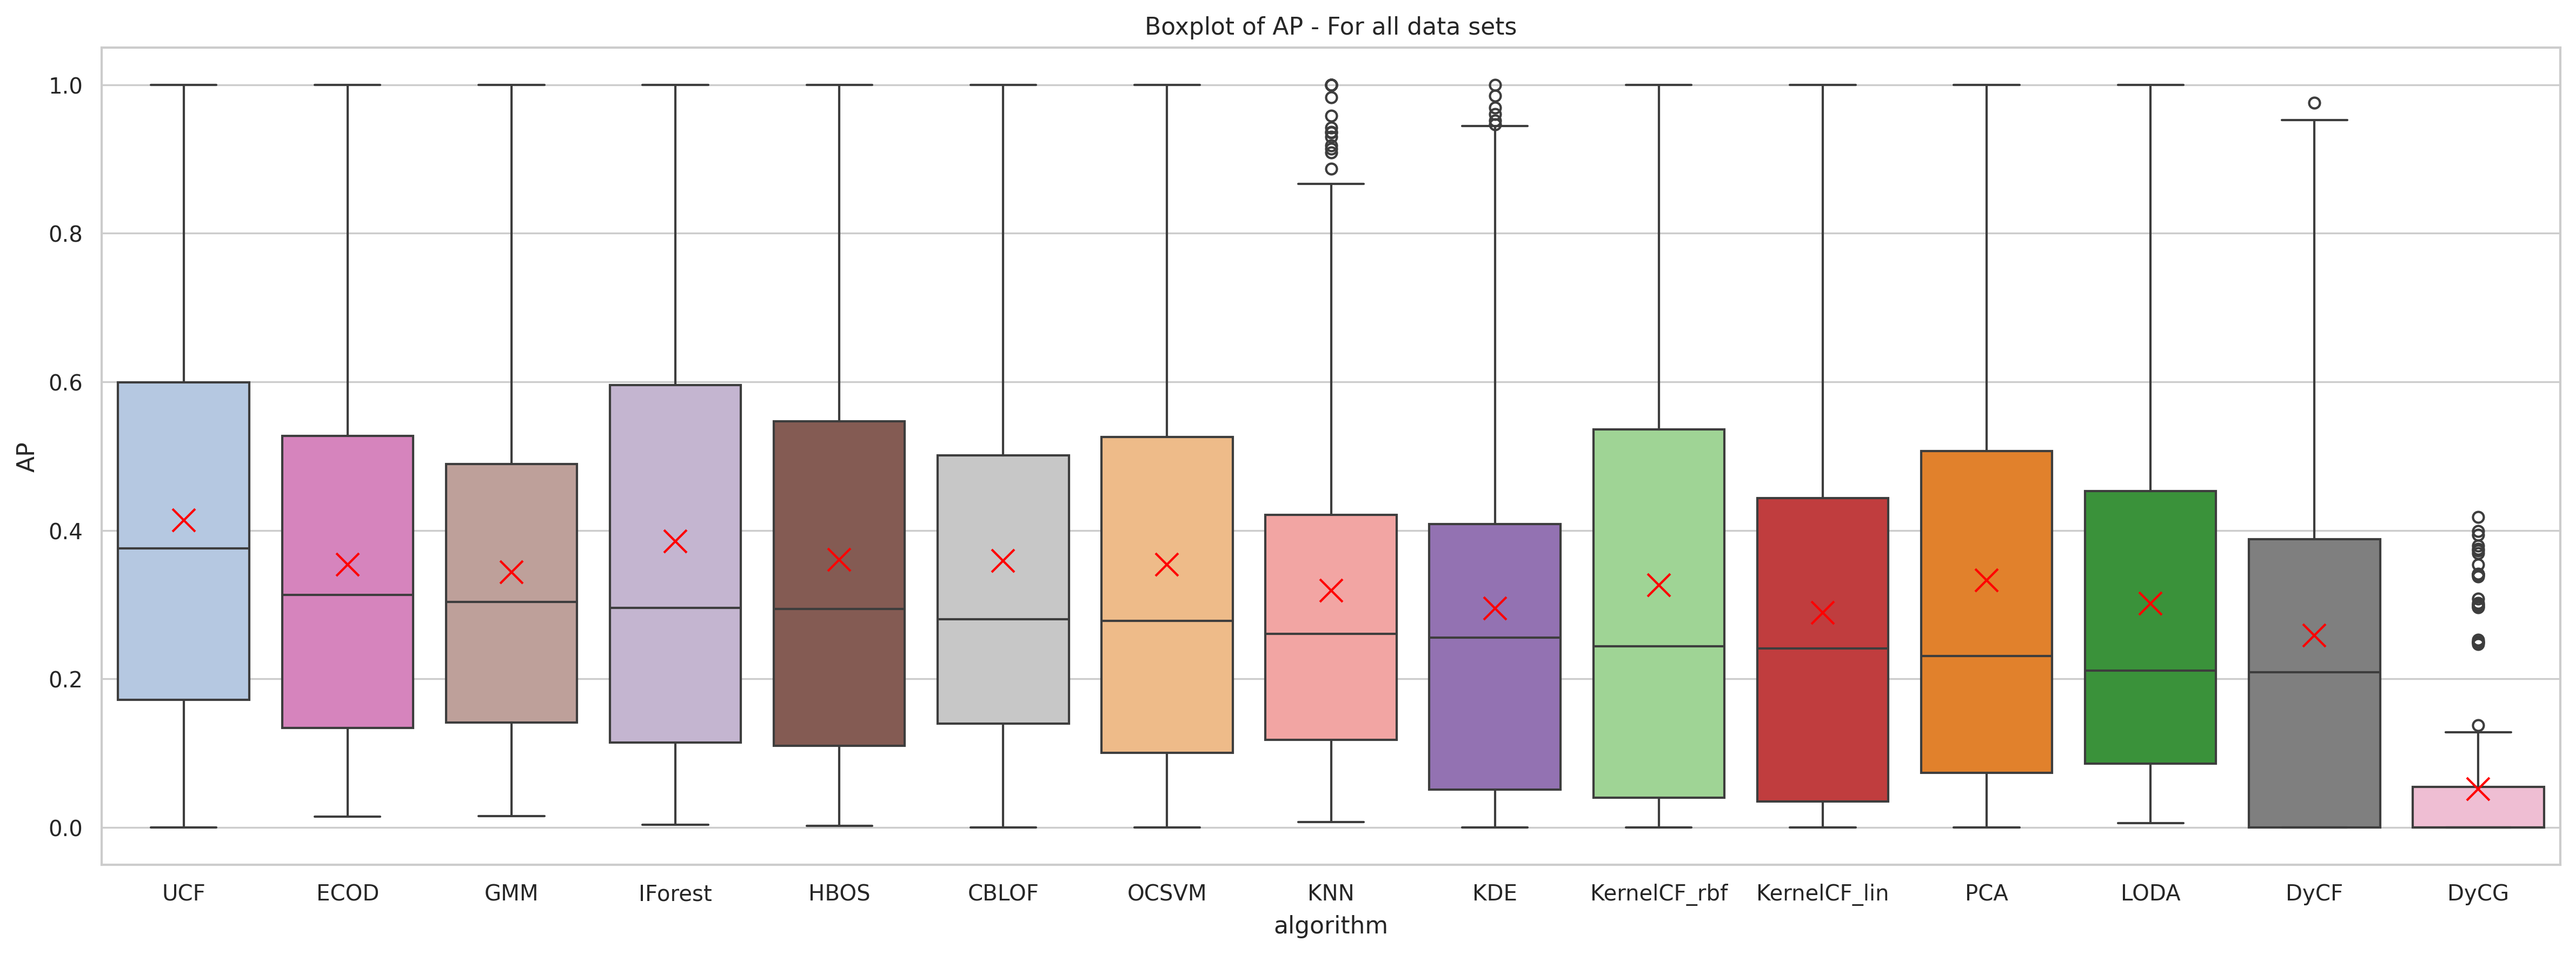

In [37]:
df = best_versions[~best_versions["algorithm"].isin(drop_cols)]
palette = {alg: color for alg, color in zip(sorted(best_versions["algorithm"].unique())[::-1], plt.cm.tab20.colors)}
title="For all data sets"
create_boxplot(df, y="auprc", metric_name="AP", rank=False, info=title, palette=palette, violin=False, ascending=False)
plt.show()

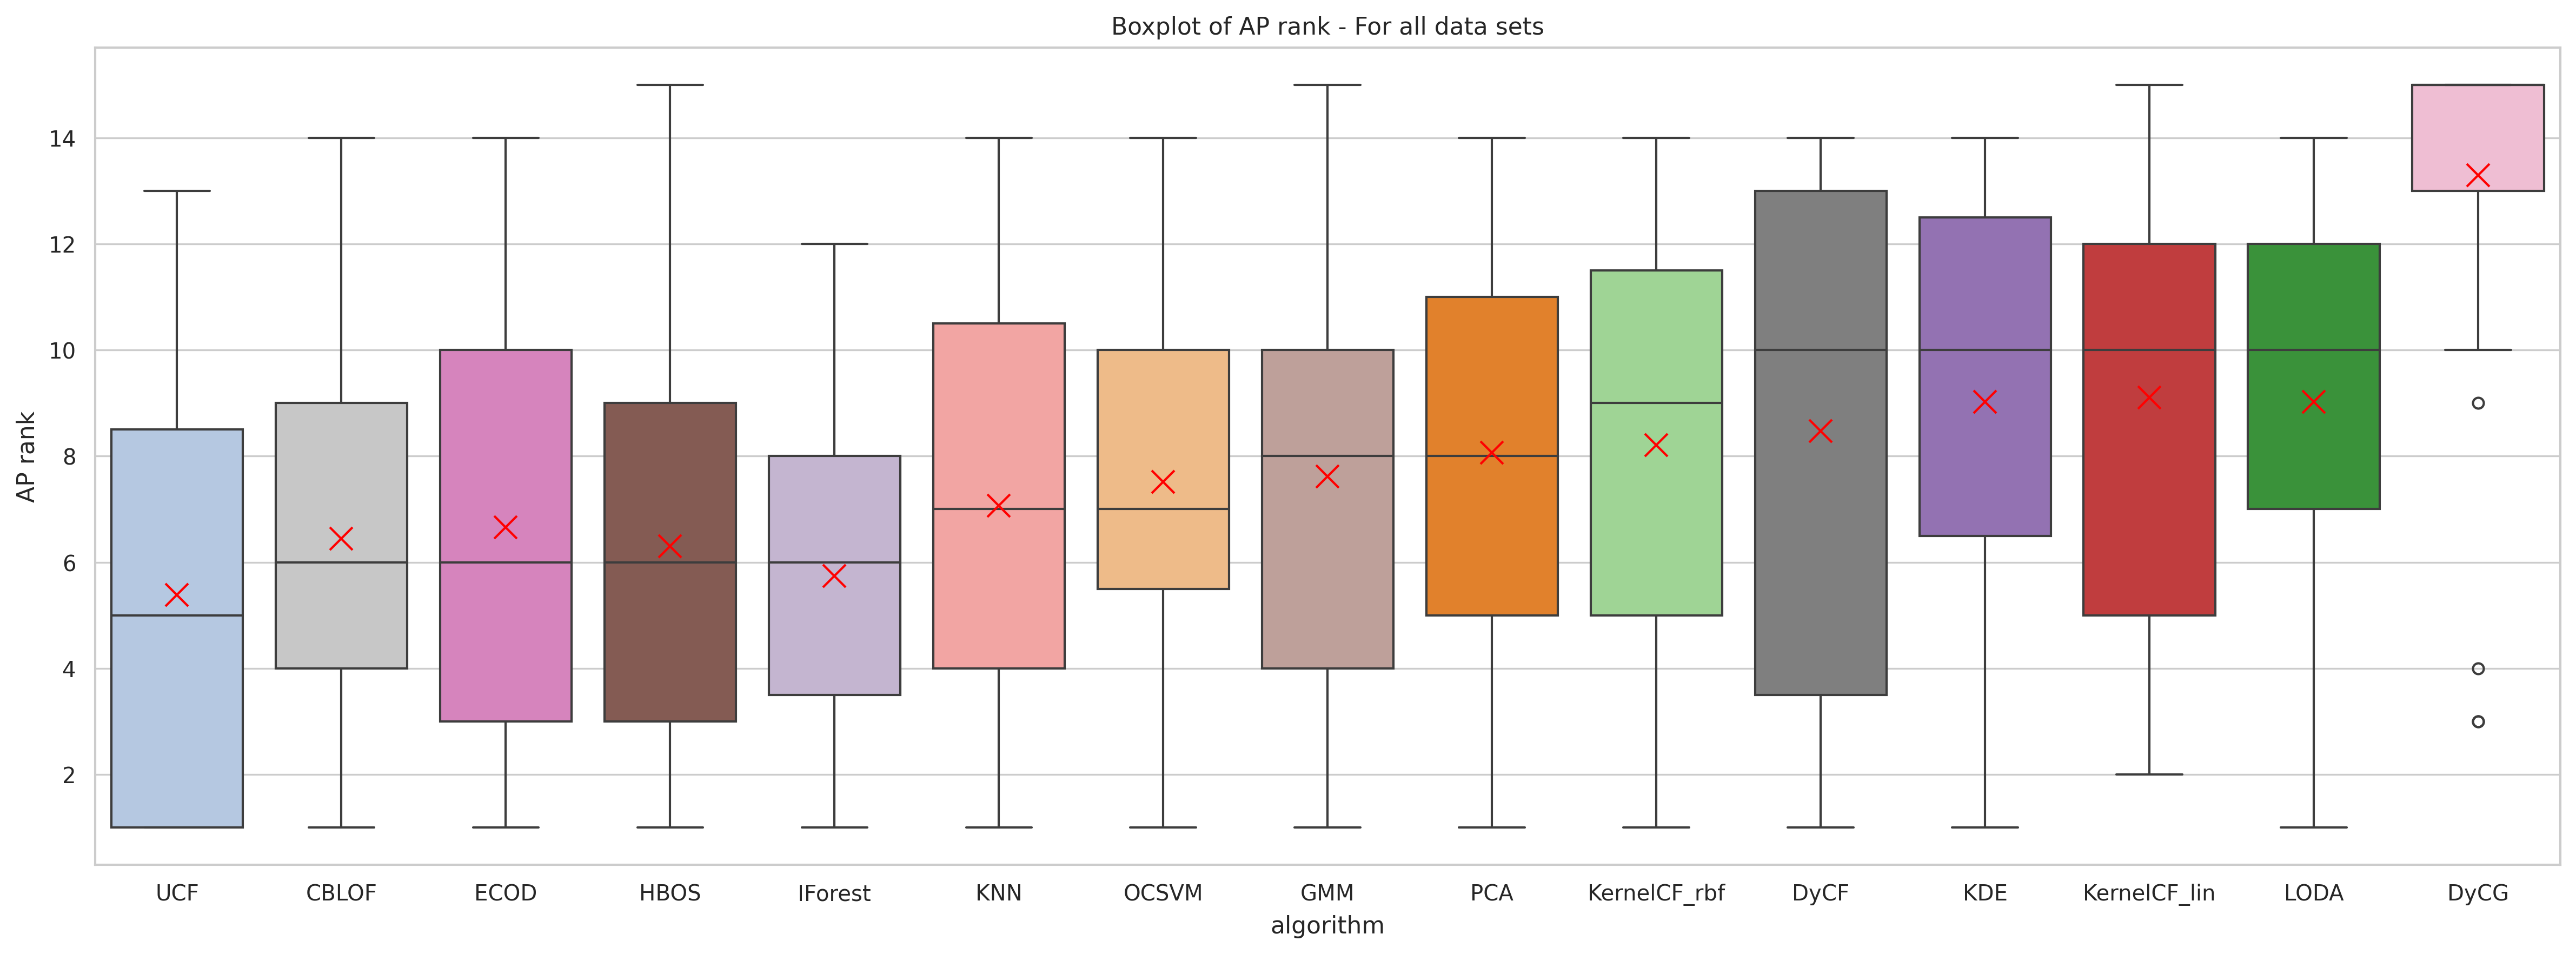

In [38]:
df = best_versions[~best_versions["algorithm"].isin(drop_cols)]
palette = {alg: color for alg, color in zip(sorted(best_versions["algorithm"].unique())[::-1], plt.cm.tab20.colors)}
title="For all data sets"
create_boxplot(df, y="auprc", metric_name="AP", rank=True, info=title, palette=palette, violin=False)
plt.show()

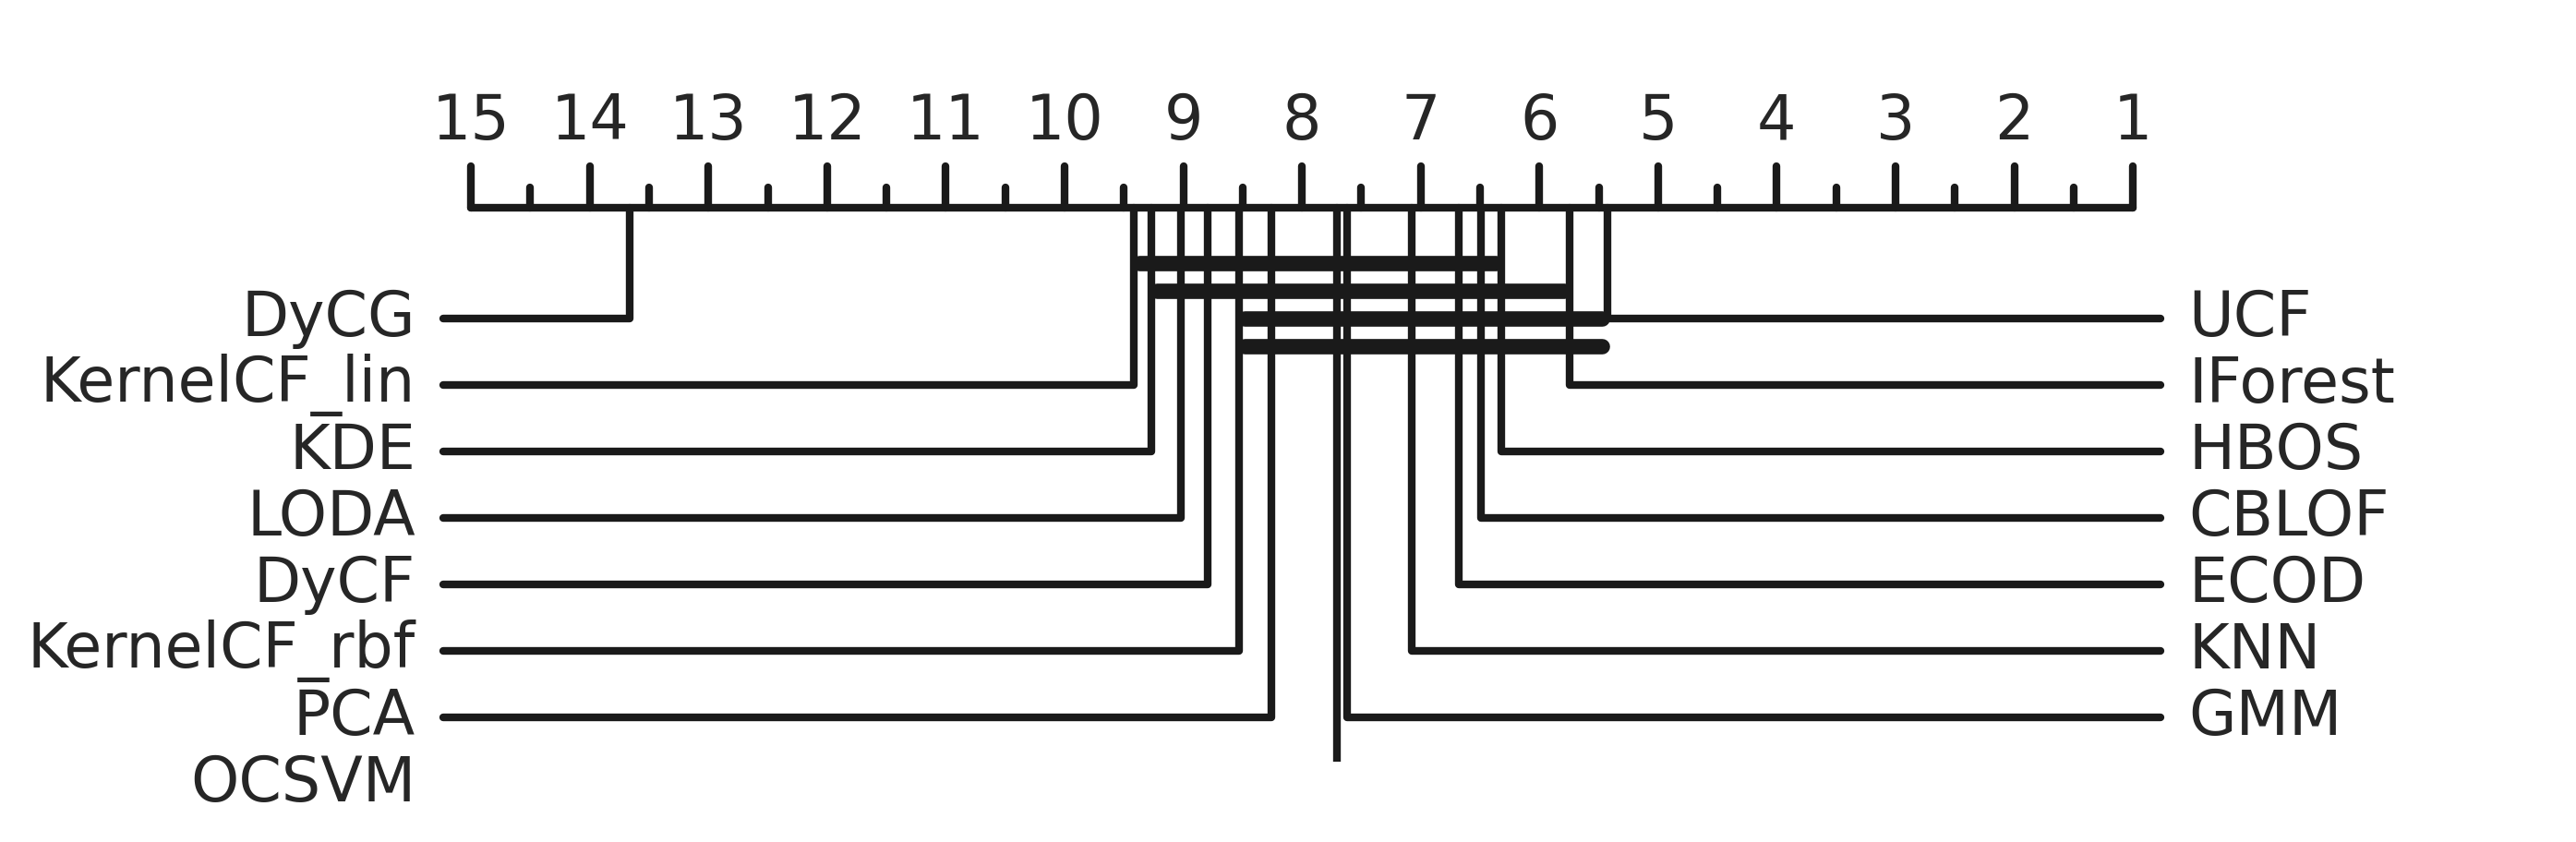

In [39]:
df = best_versions[~best_versions["algorithm"].isin(drop_cols)].copy()
draw_cd_diagram(df)

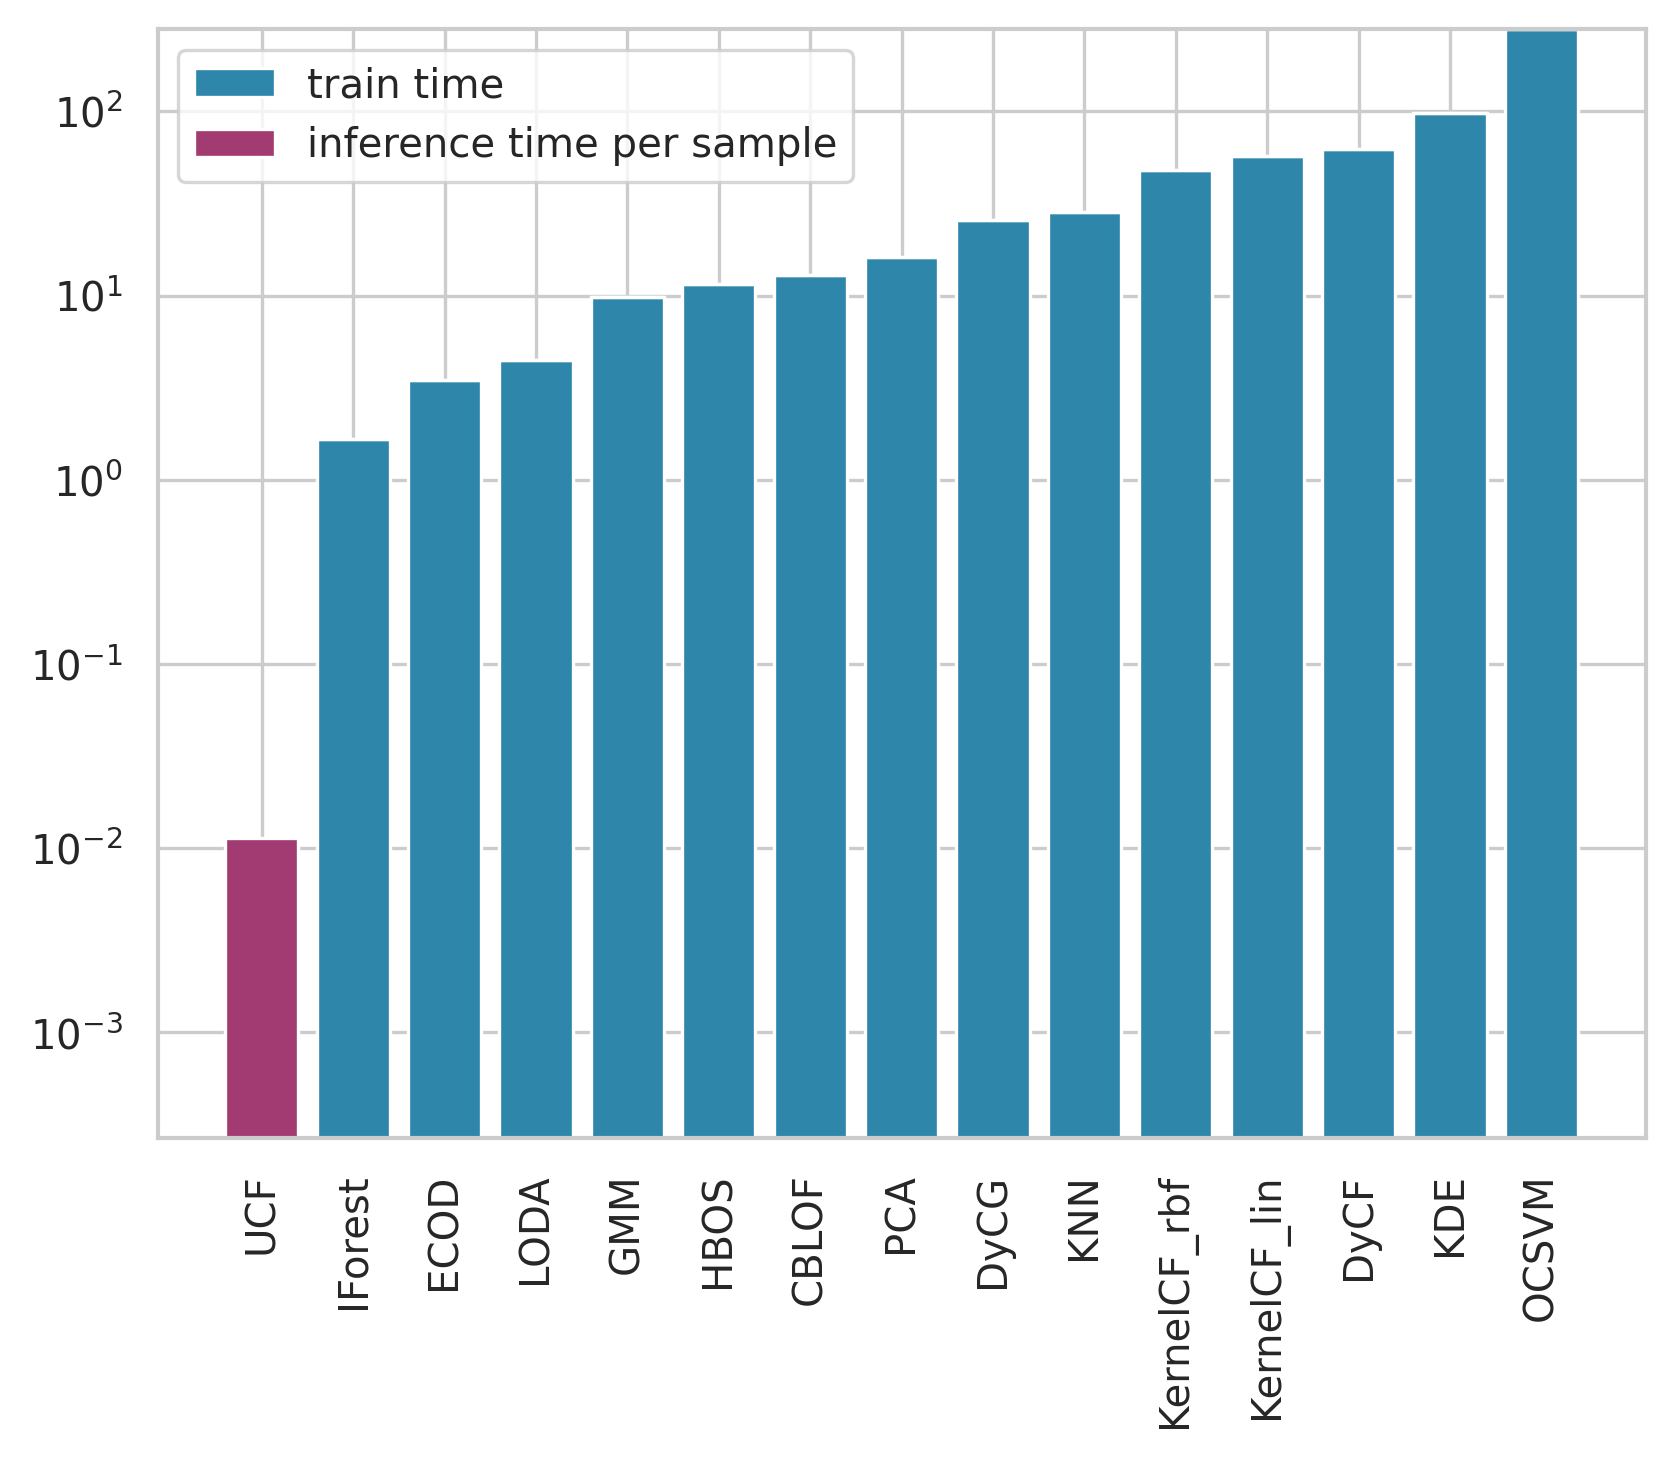

In [46]:
df = best_versions[~best_versions["algorithm"].isin(drop_cols)].copy()
df["inference_sample_time"] = df["inference_time"] / (0.3*df["N"]) # Replace by test_size_ratio
df["new_total_time"] = df["train_time"] + df["inference_sample_time"]
plt.figure()
df2 = df.groupby("algorithm")[["train_time", "inference_sample_time", "new_total_time"]].mean().reset_index()
df2 = df2.sort_values("new_total_time")
plt.bar(df2["algorithm"], df2["train_time"], label="train time")
plt.bar(df2["algorithm"], df2["inference_sample_time"], bottom=df2["train_time"], label="inference time per sample")
plt.legend()
plt.yscale("log")
plt.xticks(rotation=90)
plt.show()

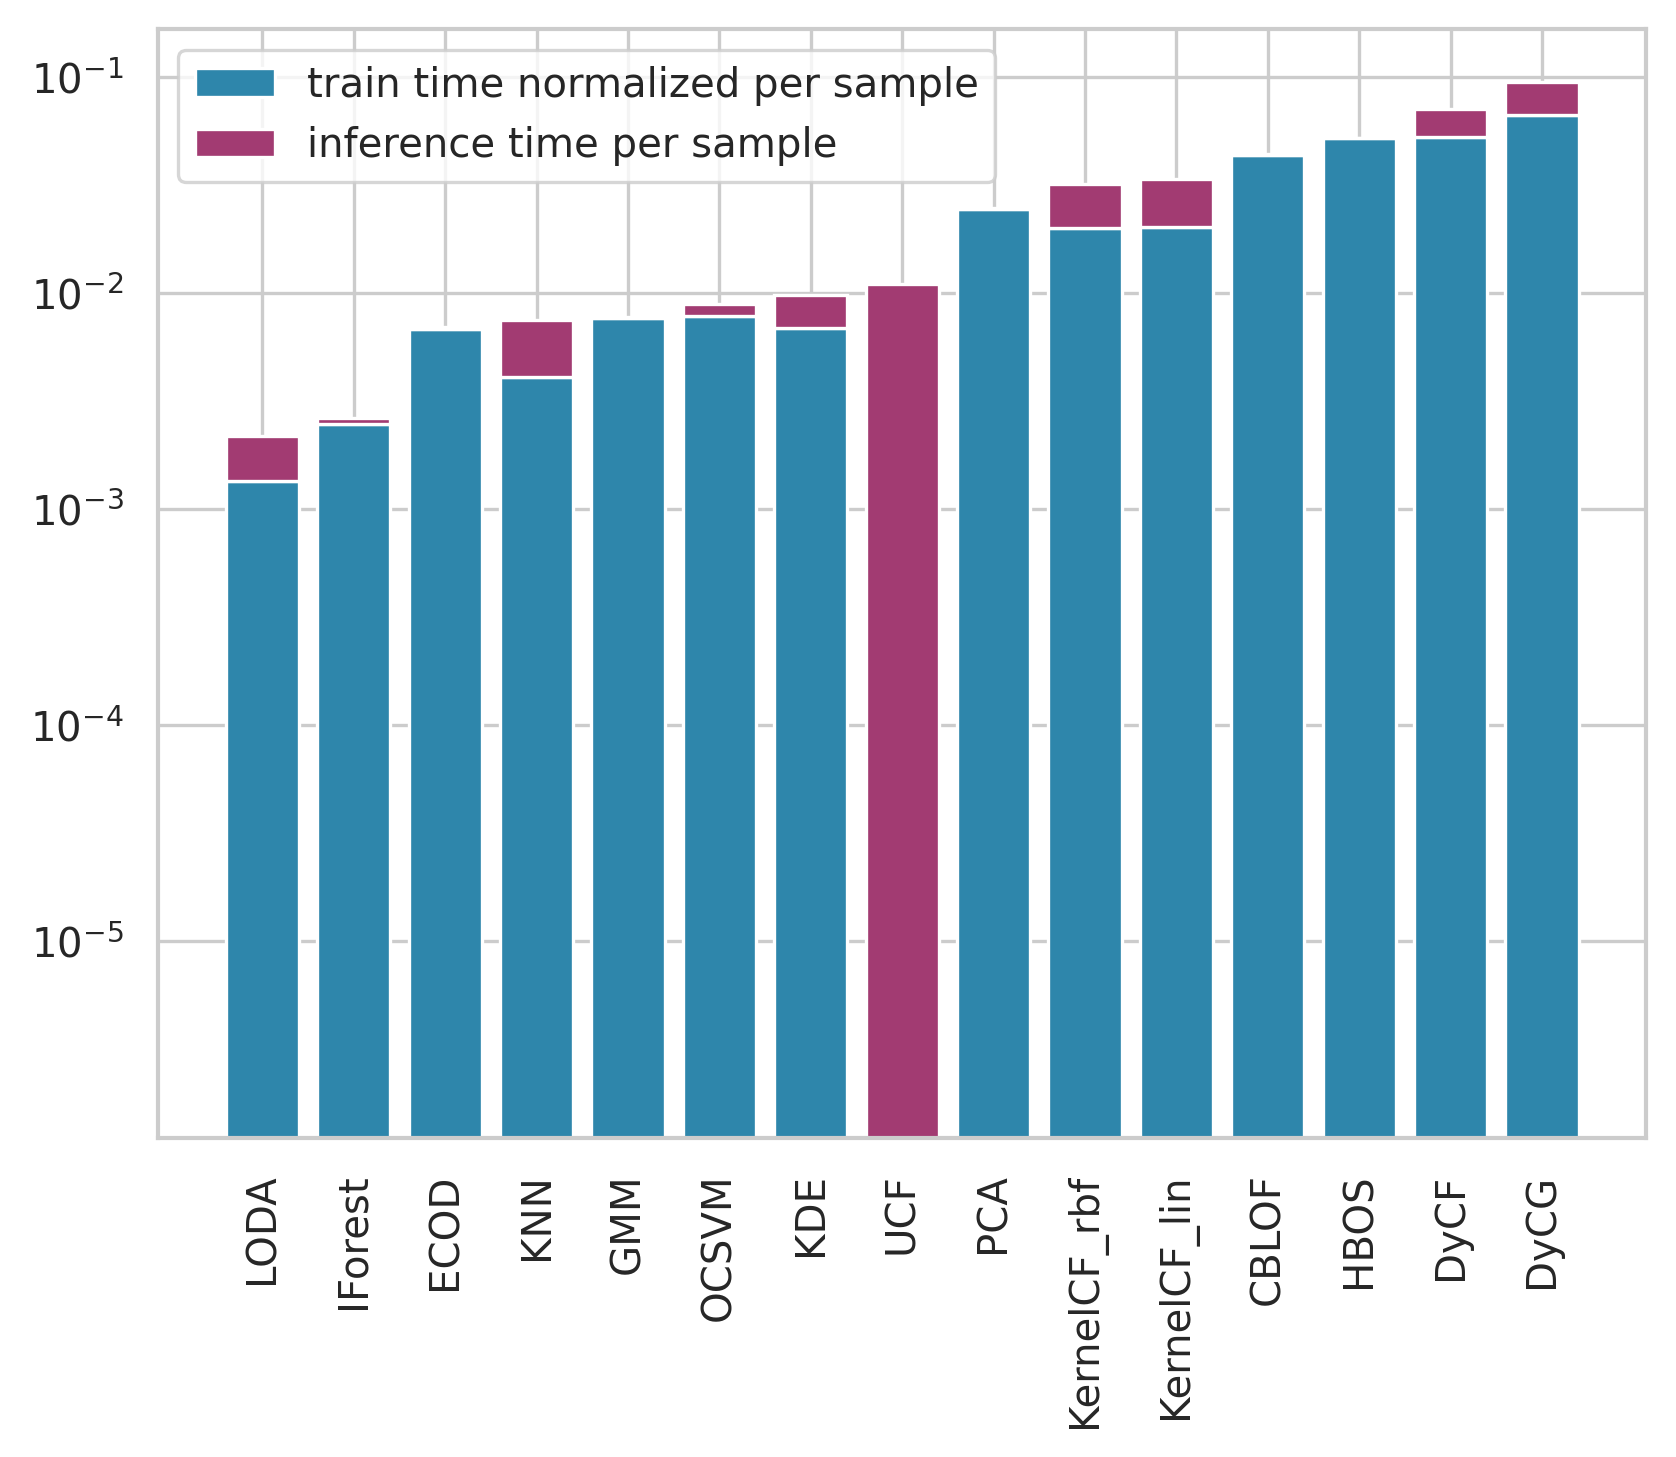

In [45]:
df = best_versions[~best_versions["algorithm"].isin(drop_cols)].copy()
for col in ["train_time", "inference_time", "total_time"]:
    df[col] = df[col] / (0.3*df["N"]) # Replace by test_size_ratio
plt.figure()
df2 = df.groupby("algorithm")[["train_time", "inference_time", "total_time"]].mean().reset_index()
df2 = df2.sort_values("total_time")
plt.bar(df2["algorithm"], df2["train_time"], label="train time normalized per sample")
plt.bar(df2["algorithm"], df2["inference_time"], bottom=df2["train_time"], label="inference time per sample")
plt.legend()
plt.yscale("log")
plt.xticks(rotation=90)
plt.show()

### Other plots

In [ ]:
plot_res(best_versions, title="All datasets")

In [ ]:
for category_type in best_versions["category"].unique():
    plot_res(best_versions[best_versions["category"] == category_type].copy(), title=category_type)

In [ ]:
for category_type in best_versions["anomaly_ratio"].unique():
    plot_res(best_versions[best_versions["anomaly_ratio"] == category_type].copy(), title=category_type)